# Autoregressive Models: NADE and FVSBN

In this assignment, you will implement and train a Neural Autoregressive Density Estimator (NADE) model on the MNIST dataset, analyze its sampling behavior and training dynamics, and adapt the code to explore its differences from a simpler FVSBN model. The starter code provides the foundation while leaving key components for you to complete, along with conceptual questions that test your understanding of autoregressive modeling principles and practical implementation challenges. Through this hands-on exercise, you will gain experience with both the theoretical and applied aspects of modern autoregressive architectures.


## Part 1: Setup
### Import necessary libraries

In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

import os
from datetime import datetime

### Load MNIST dataset

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.59MB/s]


In [3]:
print(train_loader.dataset)
print(test_loader.dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
           )


## Part 2: Explore and visualize data
### Visualize samples

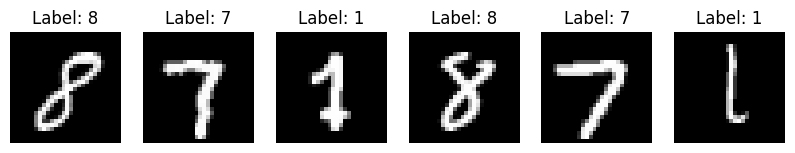

In [4]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(10, 3))
for i in range(6):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Label: {labels[i].item()}')
plt.show()

### Selective subset training
For a faster training, only train ona subset of images from each digit (class)

### TODO:
- Training AR models could be VERY slow. To make the task more feasible for our assignment, create a balanced subset of the training set; i.e., randomly pick 1000 images of each digit
- Update train_loader accordingly

In [5]:
samples_per_class = 1000
torch.manual_seed(123)

'''  Create train_subset as a subset of the original training set based on the given instruction   '''
selected_indices = []

for digit in range(10):

    digit_indices=torch.where(train_dataset.targets==digit)[0]
    shuffled_indices=digit_indices[torch.randperm(len(digit_indices))]
    selected_indices.append(shuffled_indices[:samples_per_class])

selected_indices = torch.cat(selected_indices).tolist()

train_subset = torch.utils.data.Subset(train_dataset,selected_indices)

'''  Update train_loader based on created train_subset   '''
train_loader =  DataLoader(train_subset,batch_size=64,shuffle=True)

### Selective digit training
For even faster training practice, only focuse on a subset of digits that are easier to learn

### TODO:
- To make the AR training task even faster, keep only two digits of 1 & 7 (easier to learn) from the training and test sets
- Create training_focused_loader and test_focused_loader according to the updated training and test sets

In [6]:
# Train only on digits 1 and 7 (easiest to learn)
digit_filter = [1, 7]

'''  Keep only digits in digit_filter in the training and test sets   '''
train_focused = [sample for sample in train_subset if sample[1] in digit_filter]
test_focused = [sample for sample in test_dataset if sample[1] in digit_filter]

'''  Update train_loader based on created train_subset   '''
training_focused_loader = DataLoader(train_focused, batch_size=128, shuffle=True)
test_focused_loader = DataLoader(test_focused, batch_size=128, shuffle=False)

## Part 3: Implement AR

### TODO:
- Complete the code below

In [ ]:
# 5. NADE Model
class NADE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512):
        """Initialize the Neural Autoregressive Density Estimation model.

        Args:
            input_dim (int): Dimension of input data (flattened image size)
            hidden_dim (int): Number of units in hidden layer
        """
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.W = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.c = nn.Parameter(torch.zeros(hidden_dim))
        self.V = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(input_dim))

        # Training metadata
        self.start_epoch = 0
        self.best_loss = float('inf')
        self.train_history = []
        self.test_history = []

    def forward(self, x):
        """Forward pass through the NADE model.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim)

        Returns:
            tuple: (x_hat, all_h) where:
                x_hat: reconstructed probabilities for each dimension
                all_h: all hidden states during autoregressive process
        """
        batch_size = x.size(0)
        x_hat = torch.zeros_like(x)
        all_h = []
        for d in range(self.input_dim):
            # Compute pre-activation for dimension d:
            # a_d = c + sum_{k<d} x_k * W_k
            a_d = self.c +  torch.matmul(x[:, :d], self.W[:d])
            h_d = torch.sigmoid(a_d)
            # Compute output probability for dimension d:
            # p_d = sigmoid(b_d + V.T h_d)
            p_d = torch.sigmoid(self.b[d] + torch.matmul(h_d, self.V[:, d]))
            x_hat[:, d] = p_d
            all_h.append(h_d)
        return x_hat, torch.stack(all_h, dim=1)

    def log_prob(self, x):
        """Compute log probability of input samples under the model.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim)

        Returns:
            torch.Tensor: Log probabilities for each sample (batch_size)
        """
        x_hat, _ = self.forward(x)
        # Compute Bernoulli log likelihood:
        # log p(x) = sum_d [x_d * log(p_d) + (1-x_d) * log(1-p_d)]  --- update this in order to avoid log of zero
        log_prob = x * torch.log(x_hat + 1e-6) + (1 - x) * torch.log(1 - x_hat + 1e-6)


        # Sum over all dimensions (input_dim)
        return log_prob.sum(dim=1)


    def generate_samples(self, num_samples=10):
        """
        Generates new images via ancestral sampling
        Args:
            num_samples: How many images to generate
        Returns:
            Tensor of shape (num_samples, input_dim)
        """
        samples = torch.zeros(num_samples, 784).to(device)
        with torch.no_grad():
            for d in range(784):
                p_d = self.forward(samples)[0][:, d]
                samples[:, d] = torch.bernoulli(p_d)
        return samples.cpu()


In [ ]:
# The code runs faster if you run on GPU. Select Runtime -> Change runtime type -> T4 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Part 4: Train the model

### TODO:
- Complete the code below



In [ ]:
model = NADE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 300
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for batch, _ in training_focused_loader:
        batch = batch.view(-1, 784).to(device)
        optimizer.zero_grad()
        loss = -model.log_prob(batch).mean()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation: similar to training, except no optimization and backward steps
    model.eval()
    with torch.no_grad():
        test_loss = 0.0
        for batch, _ in test_focused_loader:
            batch = batch.view(-1, 784).to(device)
            test_loss += -model.log_prob(batch).mean().item()
        avg_test_loss = test_loss / len(test_focused_loader)
        test_losses.append(avg_test_loss)


    # For each epoch, print: epoch number, training loss, and test loss
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")


Epoch 1/300, Train Loss: 49.4999, Test Loss: 425.5597
Epoch 2/300, Train Loss: 39.0508, Test Loss: 338.5981
Epoch 3/300, Train Loss: 31.5670, Test Loss: 279.0553
Epoch 4/300, Train Loss: 26.6029, Test Loss: 240.4341
Epoch 5/300, Train Loss: 23.4168, Test Loss: 215.9059
Epoch 6/300, Train Loss: 21.3714, Test Loss: 199.8824
Epoch 7/300, Train Loss: 20.0492, Test Loss: 189.1200
Epoch 8/300, Train Loss: 19.1297, Test Loss: 181.5128
Epoch 9/300, Train Loss: 18.4592, Test Loss: 175.9770
Epoch 10/300, Train Loss: 17.9696, Test Loss: 171.7171
Epoch 11/300, Train Loss: 17.5854, Test Loss: 168.3822
Epoch 12/300, Train Loss: 17.2807, Test Loss: 165.7184
Epoch 13/300, Train Loss: 17.0106, Test Loss: 163.5070
Epoch 14/300, Train Loss: 16.8231, Test Loss: 161.6036
Epoch 15/300, Train Loss: 16.6440, Test Loss: 159.9880
Epoch 16/300, Train Loss: 16.4796, Test Loss: 158.5319
Epoch 17/300, Train Loss: 16.3534, Test Loss: 157.2785
Epoch 18/300, Train Loss: 16.2053, Test Loss: 156.0451
Epoch 19/300, Train

# Part 5: Analyze Results

### TODO:

Clearly plot the following curves and include explanations for each:

- Plot the training loss (average per epoch).

- Plot the test loss (average per epoch).

- Did the model converge?


<div dir='rtl' align='justify'>
بله مدل همگرا شده است زیرا تقریبا از ایپاک 100 به بعد دیگر تغییر چندانی در خطای تست ایجاد نمیشود و به سمت یک خط راست میل میکنند. برای خطای آموزشی نیز این مسئله بر قرار است بنابرین مدل همگرا شده است.

</div>

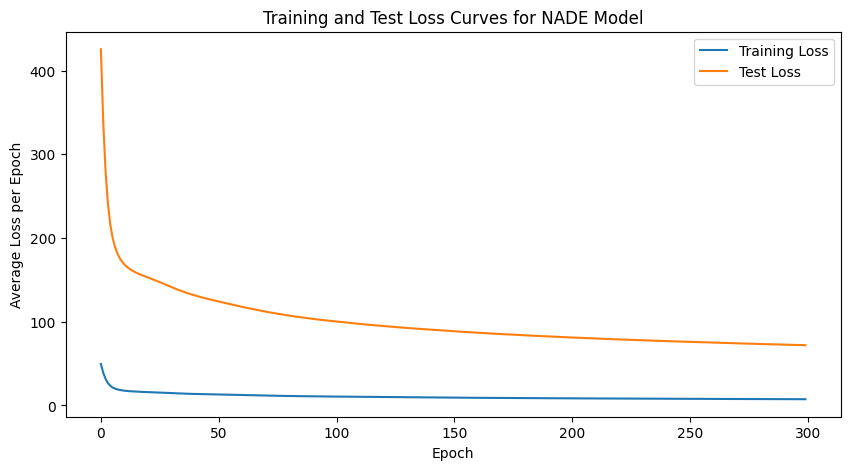

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Average Loss per Epoch")
plt.legend()
plt.title("Training and Test Loss Curves for NADE Model")
plt.show()


# Part 6: Generate and visualize samples


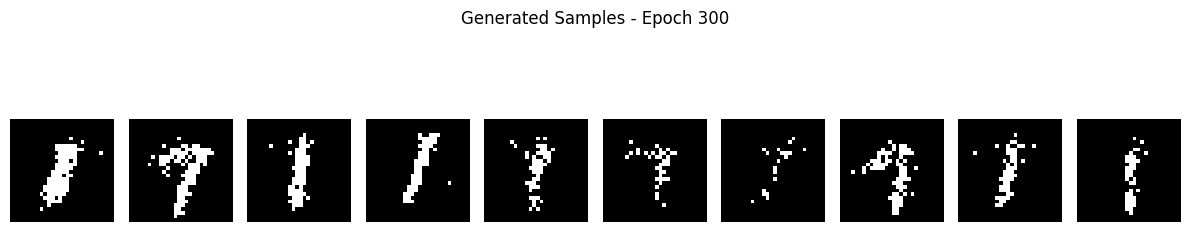

In [ ]:
samples = model.generate_samples()
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(samples[i].view(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle(f"Generated Samples - Epoch {epoch+1}")
plt.tight_layout()
plt.show()

## Part 7: Bonus
### TODO:
1. Model Implementation
Implement an FVSBN model using the same filtered MNIST dataset. Carefully analyze how the autoregressive structure differs in implementation from NADE, particularly in how conditional dependencies are modeled between pixels. What modifications were required in the training loop to accommodate these architectural differences?
<div dir='rtl' align='justify'>
در حلقه training نیاز نیست تغییراتی اعمال شود اما در قسمت forward کلاس مدل FVSBN لایه پنهان باید حذف شود و متغییر های ورودی با ساختار autoregressive با ضرب یک بردار ضرایب و عبور از یک لایه تابع فعالساز sigmoid به خروجی بروند. ساختار کلی مدل همان autoregressive بوده و تنها تفاوت حذف لایه پنهان است. در واقع برای برآورد هر x_i، ضرایب متناسب با ورودی های کوچکتر از i قبلی با مقدار ورودی آنها ضرب شده و مجموعه آنها از یک تابع فعالساز sigmoid عبور میکنند.
</div>
2. Architectural Comparison
Compare and contrast the model structures of FVSBN and NADE by addressing:

  (a) How the conditional probability p(x_i|x_<i) is computed differently in each architecture
  <div dir='rtl' align='justify'>
  در مدل NADE ابتدا ورودی ها در هر مرحله i با ضرب در ضرایب لایه پنهان متناسبشان به بعد لایه پنهان میروند. در نهایت خروجی
   iامین ستون از ماتریس ضرایب لایه خروجی با خروجی های لایه پنهان ضرب میشود که خروجی های لایه پنهان را از بعد خودشان به بعد خروجی میبرند و  خروجی iام یعنی احتمال P(x_i|x_< i) را ایجاد میکند. اما در مدل FVSBN ورودی های مدل بعنی x_< i ها مستقیما با ضرایب متناسبشان ضرب شده و جمع شده و خروجی مدل را میسازند. در واقع تفاوت اصلی در این است که مدل NADE میتواند از لایه پنهان عبور کن تا مدل پیچیدگی داده ها را بهتر یاد بگیرد که هزینه آن، به شدت زیاد شدن ضرایب است و بار محاسباتی را افزایش میدهد. اما FVSBN ضرایب کمتری دارد اما مدل سخت تر میتوان پیچیدگی داده ها را یاد بگیرد ولی بار محاسباتی آن کمتر است. این مدل برای زمان هایی که داده ها پیچیدگی کمتری داشته باشند میتواند مناسب باشد.
  </div>

  (b) The role of hidden units in NADE versus direct parameterization in FVSBN
  <div dir='rtl' align='justify'>
لایه پنهان در مدل NADE میتواند ویژگی های بیشتری از داده را یاد بگیرد که به دقت مدل در داده های پیچیده کمک میکند درحالی که در مدل FVSBN به دلیل پارامترگذاری مستقیم نمیتواند ویژگی های زیادی از داده ها را یاد بگیرد و در داده های پیچیده دقت خوبی نشان نمیدهد.
  </div>
  (c) The memory requirements for each model given an input dimension D. Support your analysis with specific equations from both architectures.
  <div dir='rtl' align='justify'>
در مدل FVSBN، هر x_i با استفاده از رگرسیون لجستیک به شرط  ورودی‌ های قبلی مدل میشود و در نتیجه به 2/(D×(D-1)) وزن به اضافه‌  D بایاس نیاز دارد. بنابراین تعداد کل پارامترهای این مدل بصورت  O(D^2) رشد میکند. در مقابل NADE برای محاسبه احتمال های شرطی از یک لایه‌ پنهان با اندازه H استفاده میشود. بنابراین تعداد کل پارامتر های مدل NADE به صورت O(H×D) رشد میکند. چون برای لایه پنهان D×H پارمتر داریم و در لایه خروجی هم H×D پارامتر داریم در نتیجه بار محاسباتی در همان اوردر ضرب H و D رشد میکند
        </div>
3. Empirical Evaluation
Design a systematic comparison between your trained FVSBN and NADE models by evaluating:

  (a) Training convergence rates using identical hyperparameters
  <div dir='rtl' align='justify'>
مدل FVSBN هم با learning rate و تعداد ایپاک برابر با مدل NADE، بعد از ایپاک 100 تقریبا همگرا میشود ولی در مقدار خطای تست بالاتری به همگرایی میرسد. مدل NADE تقریبا در مقدار خطای 70 برای داده تست به همگرایی میرسد درحالی که FVSBN  در حدود خطای 280 به همگرایی میرسد. این مسئله برای خطای داده آموزشی نیست صادق است.
  </div>
  (b) Sample quality through both visual inspection and quantitative metrics (e.g., log-likelihood on test set)
   <div dir='rtl' align='justify'>
همانطور که در خروجی تصاویر تولید شده با مدل FVSBN دیده میشود تصاویر تولید شده اصلا شباهتی به تصاویر داده آموزشی ندارند و بسیار بی کیفیت تر از تصاویر تولید شده با مدل NADE هستند. همچنین  لگاریتم تابع درستمایی برای آخرین ایپاک مدل NADE، -71.9364 است در حالی که مقدار این معیار در آخرین ایپاک مدل FVSBN برابر -283.3972 است.
  </div>

  (c) Computational efficiency during both training and generation. What fundamental architectural characteristics explain the performance differences you observe?
  <div dir='rtl' align='justify'>
بار محاسباتی هم در آموزش مدل و هم در تولید تصاویر در مدل FVSBN به بسیار کمتر از مدل NADE است. و کم بودن تعداد پارامتر های مدل این مسئله را توجیه میکند. مدل NADE میتواند لایه پنهان با تعداد node های دلخواه باشد که تعداد پارامتر های مدل را به سدت افزایش میدهد و بار محاسباتی در آموزش و تولید نمونه سنگین تر میکند.
  </div>

In [7]:
# 5. FVSBN Model
class FVSBN(nn.Module):
    def __init__(self, input_dim=784):
        """Initialize the Neural Autoregressive Density Estimation model.

        Args:
            input_dim (int): Dimension of input data (flattened image size)
        """
        super().__init__()
        self.input_dim = input_dim
        self.W = nn.Parameter(torch.randn(input_dim,input_dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(input_dim))

        # Training metadata
        self.start_epoch = 0
        self.best_loss = float('inf')
        self.train_history = []
        self.test_history = []

    def forward(self, x):
        """Forward pass through the NADE model.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim)

        Returns:
            tuple: (x_hat, all_h) where:
                x_hat: reconstructed probabilities for each dimension
        """
        batch_size = x.size(0)
        x_hat = torch.zeros_like(x)

        for d in range(self.input_dim):

            p_d = torch.sigmoid(self.b[d] + torch.matmul(x[:, :d], torch.t(self.W[d,:d])))
            x_hat[:, d] = p_d
        return x_hat

    def log_prob(self, x):
        """Compute log probability of input samples under the model.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim)

        Returns:
            torch.Tensor: Log probabilities for each sample (batch_size)
        """
        x_hat = self.forward(x)
        # Compute Bernoulli log likelihood:
        # log p(x) = sum_d [x_d * log(p_d) + (1-x_d) * log(1-p_d)]  --- update this in order to avoid log of zero
        log_prob=x*torch.log(x_hat+1e-5)+(1-x)*torch.log(1-x_hat+1e-5)


        # Sum over all dimensions (input_dim)
        return log_prob.sum(dim=1)


    def generate_samples(self, num_samples=10):
        """
        Generates new images via ancestral sampling
        Args:
            num_samples: How many images to generate
        Returns:
            Tensor of shape (num_samples, input_dim)
        """
        samples = torch.zeros(num_samples, 784).to(device)
        with torch.no_grad():
            for d in range(784):
                p_d = self.forward(samples)[:, d]
                samples[:, d] = torch.bernoulli(p_d)
        return samples.cpu()

In [8]:
# The code runs faster if you run on GPU. Select Runtime -> Change runtime type -> T4 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
model = FVSBN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 300
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for batch, _ in training_focused_loader:
        batch = batch.view(-1, 784).to(device)
        optimizer.zero_grad()
        loss = -model.log_prob(batch).mean()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation: similar to training, except no optimization and backward steps
    model.eval()
    with torch.no_grad():
        test_loss = 0.0
        for batch, _ in test_focused_loader:
            batch = batch.view(-1, 784).to(device)
            test_loss += -model.log_prob(batch).mean().item()
        avg_test_loss = test_loss / len(test_focused_loader)
        test_losses.append(avg_test_loss)


    # For each epoch, print: epoch number, training loss, and test loss
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

Epoch 1/300, Train Loss: 54.5320, Test Loss: 525.4821
Epoch 2/300, Train Loss: 52.7282, Test Loss: 508.5654
Epoch 3/300, Train Loss: 51.0654, Test Loss: 492.9445
Epoch 4/300, Train Loss: 49.5385, Test Loss: 478.5831
Epoch 5/300, Train Loss: 48.1487, Test Loss: 465.4184
Epoch 6/300, Train Loss: 46.8594, Test Loss: 453.3631
Epoch 7/300, Train Loss: 45.6827, Test Loss: 442.2641
Epoch 8/300, Train Loss: 44.5909, Test Loss: 432.0354
Epoch 9/300, Train Loss: 43.5971, Test Loss: 422.5611
Epoch 10/300, Train Loss: 42.6622, Test Loss: 413.7880
Epoch 11/300, Train Loss: 41.8103, Test Loss: 405.6545
Epoch 12/300, Train Loss: 41.0190, Test Loss: 398.0804
Epoch 13/300, Train Loss: 40.2661, Test Loss: 391.0318
Epoch 14/300, Train Loss: 39.5765, Test Loss: 384.4317
Epoch 15/300, Train Loss: 38.9347, Test Loss: 378.2467
Epoch 16/300, Train Loss: 38.3264, Test Loss: 372.4445
Epoch 17/300, Train Loss: 37.7557, Test Loss: 366.9864
Epoch 18/300, Train Loss: 37.2287, Test Loss: 361.8419
Epoch 19/300, Train

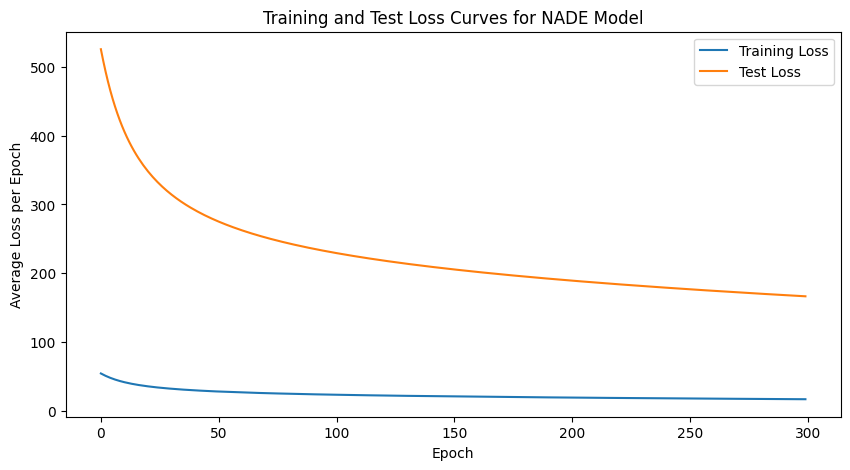

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Average Loss per Epoch")
plt.legend()
plt.title("Training and Test Loss Curves for NADE Model")
plt.show()

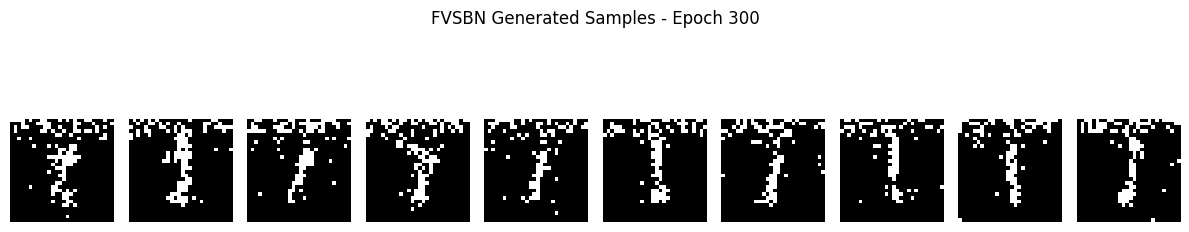

In [11]:
samples = model.generate_samples()
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(samples[i].view(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle(f"FVSBN Generated Samples - Epoch {epoch+1}")
plt.tight_layout()
plt.show()